# Consensus Algorithms & AI Misbehaviour Detection over IoT and UAV Data

**Part 1** - eight consensus algorithms + smart contracts on two open datasets (IoT and UAV), with a consolidated KPI dashboard.
**Part 2** - ten classical AI detectors + LIME/SHAP explainability, compared with confusion matrices, ROC/AUC and blockchain KPIs.

*Datasets:* TON_IoT (UNSW Canberra, 7 sensors) and UAVCAN (Pixhawk 4 UAV CAN bus, 10 attack scenarios), every record is labelled normal/attack. (make sure to add datasets to runtime on google colab)

# PART 1 — Consensus Algorithms & Smart Contracts

In [1]:
# ===== PART 1 · CELL 1.1 — Setup, configuration and measurement scaffold =====
import os, re, glob, time, random, hashlib
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- config ---
DATA_DIR       = Path(".")          # folder holding the CSV + .bin files (Colab: Path("/content"))
IOT_PER_SENSOR = 6000               # 7 x 6000 = 42,000 IoT transactions
UAV_PER_FILE   = 4200               # 10 x 4200 = 42,000 UAV transactions
BLOCK_SIZE     = 100                # transactions per block
SEEDS          = 3                  # runs per algorithm, averaged
POW_DIFFICULTY = 3                  # PoW leading-zero target (real mining)

# --- modelled assumptions (documented, not measured) ---
BYZ_FRACTION, BYZ_FRACTION_POA = 0.20, 0.05
DETECT_PROB, POA_AUDIT_PROB, RAFT_CRASH_PROB = 0.60, 0.90, 0.05
HASH_COST, MSG_COST = 1.0, 1.0

# --- styling ---
IOT_COLOR, UAV_COLOR = "#4477AA", "#EE6677"
FAMILY_COLOR = {"economic": "#4477AA", "leader": "#CCBB44", "bft": "#EE6677"}
plt.rcParams["figure.dpi"] = 110

# --- decentralisation metric ---
def gini(counts):
    xs = sorted(counts); n = len(xs); tot = sum(xs)
    if n == 0 or tot == 0: return 0.0
    return (2 * sum((i + 1) * x for i, x in enumerate(xs))) / (n * tot) - (n + 1) / n

# --- per-run counters ---
def new_stats():
    return {k: 0 for k in ("committed", "rejected_rule", "rejected_policy", "malicious_committed",
                           "malicious_rejected", "messages", "slash_events", "view_changes",
                           "elections", "hash_attempts")}

# --- weighted producer selection ---
def weighted_choice(producers, key, rng):
    tot = sum(p[key] for p in producers); pick = rng.uniform(0, tot); run = 0.0
    for p in producers:
        run += p[key]
        if pick <= run: return p
    return producers[-1]

# --- run the smart contract on a proposed block (honest producer filters; Byzantine bypasses) ---
def process_block(batch, contract, honest, st):
    for txn in batch:
        if honest:
            ok, reason = contract.validate(txn)
            if ok: st["committed"] += 1
            else:
                st["rejected_policy" if reason == "anomaly_policy" else "rejected_rule"] += 1
                if txn["is_attack"]: st["malicious_rejected"] += 1
        else:
            st["committed"] += 1
            if txn["is_attack"]: st["malicious_committed"] += 1

# --- assemble measured KPIs from counters ---
def finalise(name, family, dataset, st, rounds, elapsed, blocks_per_producer, n_producers):
    total_mal = st["malicious_committed"] + st["malicious_rejected"]
    return {
        "algorithm": name, "family": family, "dataset": dataset, "producers": n_producers,
        "integrity": st["malicious_rejected"] / total_mal if total_mal else 1.0,
        "messages": st["messages"], "msgs_per_block": st["messages"] / rounds,
        "block_time_ms": elapsed / rounds * 1000,
        "tps": st["committed"] / elapsed if elapsed > 0 else float("inf"),
        "gini": gini(blocks_per_producer),
        "energy_rel": st["hash_attempts"] / rounds * HASH_COST + st["messages"] / rounds * MSG_COST,
        "slash_events": st["slash_events"], "view_changes": st["view_changes"],
    }

print("Setup complete.")


Setup complete.


In [2]:
# ===== PART 1 · CELL 1.2 — Load both datasets into transaction streams =====

# --- IoT loader (random sample keeps normal+attack mix) ---
def load_iot(csv_path, limit=IOT_PER_SENSOR, seed=42):
    df = pd.read_csv(csv_path)
    if limit and limit < len(df): df = df.sample(limit, random_state=seed)
    sensor = os.path.basename(csv_path).replace("Train_Test_IoT_", "").replace(".csv", "")
    cols = [c for c in df.columns if c not in ("date", "time", "label", "type")]
    return [{"device": sensor, "payload": {c: r[c] for c in cols},
             "is_attack": int(r["label"]) == 1, "attack_type": r["type"]} for _, r in df.iterrows()]

# --- UAV loader (parse CAN frames; derive inter-frame timing before sampling) ---
CAN_LINE = re.compile(r'^(\w+)\s+\(([\d.]+)\)\s+(\S+)\s+([0-9A-Fa-f]+)\s+\[(\d+)\]\s*(.*)$')
def load_uav(bin_path, limit=UAV_PER_FILE, seed=42):
    frames = []
    for line in open(bin_path, errors="ignore"):
        m = CAN_LINE.match(line.strip())
        if m:
            lab, ts, _, cid, dlc, data = m.groups()
            frames.append((lab, float(ts), cid, int(dlc), [int(x, 16) for x in data.split()]))
    last_any, last_id, txns = None, {}, []
    for lab, ts, cid, dlc, b in frames:
        dt    = 0.0 if last_any is None else ts - last_any
        dt_id = -1.0 if cid not in last_id else ts - last_id[cid]
        last_any, last_id[cid] = ts, ts
        pay = {"can_id": cid, "dlc": dlc, "dt": dt, "dt_id": dt_id}
        for k in range(8): pay[f"b{k}"] = b[k] if k < len(b) else -1
        txns.append({"device": cid, "payload": pay, "is_attack": lab.lower() != "normal",
                     "attack_type": "normal" if lab.lower() == "normal" else "attack"})
    if limit and limit < len(txns): txns = random.Random(seed).sample(txns, limit)
    return txns

# --- build streams ---
iot_stream = []
for fp in sorted(glob.glob(str(DATA_DIR / "Train_Test_IoT_*.csv"))): iot_stream += load_iot(fp)
random.Random(42).shuffle(iot_stream)

uav_stream = []
for fp in sorted(glob.glob(str(DATA_DIR / "type*_label.bin")),
                 key=lambda p: int(re.search(r"type(\d+)", p).group(1))): uav_stream += load_uav(fp)
random.Random(42).shuffle(uav_stream)

IOT_ATTACK_RATE = float(np.mean([t["is_attack"] for t in iot_stream]))
UAV_ATTACK_RATE = float(np.mean([t["is_attack"] for t in uav_stream]))

# --- dataset summary table ---
print("TABLE 1.1 — Dataset summary\n")
print(pd.DataFrame({
    "Source": ["UNSW Canberra", "Pixhawk 4 UAV (CAN bus)"],
    "Files": [7, 10], "Transactions": [len(iot_stream), len(uav_stream)],
    "Attack rate": [f"{IOT_ATTACK_RATE:.1%}", f"{UAV_ATTACK_RATE:.1%}"],
}, index=["IoT (TON_IoT)", "UAV (UAVCAN)"]).to_string())


TABLE 1.1 — Dataset summary

                                Source  Files  Transactions Attack rate
IoT (TON_IoT)            UNSW Canberra      7         42000       59.7%
UAV (UAVCAN)   Pixhawk 4 UAV (CAN bus)     10         42000       36.6%


In [3]:
# ===== PART 1 · CELL 1.3 — Smart contracts (registries bootstrapped from normal traffic) =====

# --- pluggable anomaly policies ---
class OraclePolicy:                                   # Part 1: ground-truth upper bound
    def is_malicious(self, txn): return txn["is_attack"]
class AIPolicy:                                       # Part 2: trained-model prediction
    def is_malicious(self, txn): return txn.get("ai_pred", 0) == 1

# --- Contract A: IoT access control ---
class IoTAccessControlContract:
    def __init__(self, devices, policy): self.ok, self.policy = set(devices), policy
    def validate(self, txn):
        if txn["device"] not in self.ok: return False, "unauthorised_device"     # device registry
        if any(pd.isna(v) for v in txn["payload"].values()): return False, "malformed_payload"
        if self.policy.is_malicious(txn): return False, "anomaly_policy"          # policy layer
        return True, "accepted"

# --- Contract B: UAV CAN-frame authorisation ---
class UAVFrameAuthorisationContract:
    def __init__(self, ids, min_gap, policy): self.ok, self.gap, self.policy = set(ids), min_gap, policy
    def validate(self, txn):
        p = txn["payload"]
        if txn["device"] not in self.ok: return False, "unauthorised_id"          # CAN-ID registry
        if not (1 <= p["dlc"] <= 8): return False, "bad_dlc"                       # legal DLC
        if 0 <= p["dt_id"] < self.gap: return False, "rate_limit"                  # flooding guard
        if self.policy.is_malicious(txn): return False, "anomaly_policy"           # policy layer
        return True, "accepted"

# --- deploy (registries + rate limit learned from NORMAL traffic only) ---
iot_devices = sorted({t["device"] for t in iot_stream if not t["is_attack"]})
uav_ids     = sorted({t["device"] for t in uav_stream if not t["is_attack"]})
UAV_MIN_GAP = float(np.percentile([t["payload"]["dt_id"] for t in uav_stream
                                   if not t["is_attack"] and t["payload"]["dt_id"] > 0], 1))
iot_contract = IoTAccessControlContract(iot_devices, OraclePolicy())
uav_contract = UAVFrameAuthorisationContract(uav_ids, UAV_MIN_GAP, OraclePolicy())

print(f"Contract A (IoT): {len(iot_devices)} registered sensors")
print(f"Contract B (UAV): {len(uav_ids)} registered CAN IDs | rate limit {UAV_MIN_GAP*1000:.3f} ms")


Contract A (IoT): 7 registered sensors
Contract B (UAV): 20 registered CAN IDs | rate limit 0.105 ms


In [4]:
# ===== PART 1 · CELL 1.4 — The eight consensus algorithms =====

# --- 1. Proof of Work: real SHA-256 mining, hashrate-weighted winner, no slashing ---
class ProofOfWork:
    name, family = "PoW", "economic"
    def __init__(self, n=50, byz=BYZ_FRACTION, diff=POW_DIFFICULTY): self.n, self.byz, self.diff = n, byz, diff
    def run(self, txns, contract, seed=0, dataset=""):
        rng = random.Random(seed)
        M = [{"id": i, "hashrate": rng.randint(1, 100), "byz": rng.random() < self.byz, "blocks": 0} for i in range(self.n)]
        st, r, t0 = new_stats(), 0, time.perf_counter()
        for i in range(0, len(txns), BLOCK_SIZE):
            r += 1; w = weighted_choice(M, "hashrate", rng)
            nonce = 0                                                             # mine
            while not hashlib.sha256(f"{r}-{w['id']}-{nonce}".encode()).hexdigest().startswith("0" * self.diff):
                st["hash_attempts"] += 1; nonce += 1
            st["hash_attempts"] += 1; st["messages"] += self.n - 1
            process_block(txns[i:i+BLOCK_SIZE], contract, not w["byz"], st); w["blocks"] += 1
        return finalise(self.name, self.family, dataset, st, r, time.perf_counter()-t0, [m["blocks"] for m in M], self.n)

# --- 2. Proof of Stake: stake-weighted proposer, attestation committee, slashing ---
class ProofOfStake:
    name, family = "PoS", "economic"
    def __init__(self, n=50, committee=16, byz=BYZ_FRACTION, detect=DETECT_PROB):
        self.n, self.c, self.byz, self.detect = n, committee, byz, detect
    def run(self, txns, contract, seed=0, dataset=""):
        rng = random.Random(seed)
        V = [{"id": i, "stake": rng.randint(50, 200), "byz": rng.random() < self.byz, "blocks": 0} for i in range(self.n)]
        st, r, t0 = new_stats(), 0, time.perf_counter()
        for i in range(0, len(txns), BLOCK_SIZE):
            r += 1; p = weighted_choice(V, "stake", rng); st["messages"] += (self.n - 1) + self.c
            honest = not p["byz"]
            if p["byz"] and rng.random() < self.detect:                          # caught -> slash
                p["stake"] = max(1, p["stake"] // 2); st["slash_events"] += 1; honest = True
            process_block(txns[i:i+BLOCK_SIZE], contract, honest, st); p["blocks"] += 1
        return finalise(self.name, self.family, dataset, st, r, time.perf_counter()-t0, [v["blocks"] for v in V], self.n)

# --- 3. Delegated PoS: stake voting, elected delegates, deterministic schedule, strikes ---
class DelegatedProofOfStake:
    name, family = "DPoS", "economic"
    def __init__(self, holders=2000, cands=60, prod=21, strikes=3, byz=BYZ_FRACTION, detect=DETECT_PROB):
        self.h, self.nc, self.np, self.smax, self.byz, self.detect = holders, cands, prod, strikes, byz, detect
    def _elect(self, C, rng):
        for c in C: c["votes"] = 0
        for _ in range(self.h): rng.choice([c for c in C if not c["removed"]])["votes"] += rng.randint(1, 100)
        return sorted([c for c in C if not c["removed"]], key=lambda c: c["votes"], reverse=True)[:self.np]
    def run(self, txns, contract, seed=0, dataset=""):
        rng = random.Random(seed)
        C = [{"id": i, "votes": 0, "byz": rng.random() < self.byz, "blocks": 0, "strikes": 0, "removed": False} for i in range(self.nc)]
        P = self._elect(C, rng); st, r, slot, t0 = new_stats(), 0, 0, time.perf_counter()
        sched = P
        for i in range(0, len(txns), BLOCK_SIZE):
            r += 1
            if slot % len(P) == 0:                                               # deterministic order
                sched = sorted(P, key=lambda p: hashlib.sha256(f"{p['id']}-{r}".encode()).hexdigest())
            p = sched[slot % len(P)]; slot += 1; st["messages"] += self.np
            honest = not p["byz"]
            if p["byz"] and rng.random() < self.detect:
                p["strikes"] += 1; st["slash_events"] += 1; honest = True
                if p["strikes"] >= self.smax:
                    p["removed"] = True; P = self._elect(C, rng); slot = 0
                    sched = sorted(P, key=lambda q: hashlib.sha256(f"{q['id']}-{r}".encode()).hexdigest())
            process_block(txns[i:i+BLOCK_SIZE], contract, honest, st); p["blocks"] += 1
        return finalise(self.name, self.family, dataset, st, r, time.perf_counter()-t0, [c["blocks"] for c in C if c["blocks"]], self.np)

# --- 4. Proof of Authority: vetted authorities, round-robin, reputation/removal ---
class ProofOfAuthority:
    name, family = "PoA", "leader"
    def __init__(self, n=25, byz=BYZ_FRACTION_POA, audit=POA_AUDIT_PROB, minrep=50):
        self.n, self.byz, self.audit, self.minrep = n, byz, audit, minrep
    def run(self, txns, contract, seed=0, dataset=""):
        rng = random.Random(seed)
        A = [{"id": i, "rep": 100, "byz": rng.random() < self.byz, "blocks": 0, "removed": False} for i in range(self.n)]
        st, r, t0 = new_stats(), 0, time.perf_counter()
        for i in range(0, len(txns), BLOCK_SIZE):
            r += 1; act = [a for a in A if not a["removed"]]; s = act[r % len(act)]; st["messages"] += len(act)
            honest = not s["byz"]
            if s["byz"] and rng.random() < self.audit:
                s["rep"] -= 30; st["slash_events"] += 1; honest = True
                if s["rep"] < self.minrep: s["removed"] = True
            process_block(txns[i:i+BLOCK_SIZE], contract, honest, st); s["blocks"] += 1
        return finalise(self.name, self.family, dataset, st, r, time.perf_counter()-t0, [a["blocks"] for a in A], self.n)

# --- 5. Proof of Capacity: plot-weighted deadlines from real hashing, no slashing ---
class ProofOfCapacity:
    name, family = "PoC", "economic"
    def __init__(self, n=50, byz=BYZ_FRACTION): self.n, self.byz = n, byz
    def run(self, txns, contract, seed=0, dataset=""):
        rng = random.Random(seed)
        F = [{"id": i, "plot": rng.randint(1, 100), "byz": rng.random() < self.byz, "blocks": 0} for i in range(self.n)]
        st, r, t0 = new_stats(), 0, time.perf_counter()
        for i in range(0, len(txns), BLOCK_SIZE):
            r += 1; ch = hashlib.sha256(f"c{r}".encode()).hexdigest()
            def dl(f):
                st["hash_attempts"] += 1
                return (int(hashlib.sha256(f"{f['id']}-{ch}".encode()).hexdigest()[:12], 16) % 10**6) / f["plot"]
            w = min(F, key=dl); st["messages"] += self.n - 1
            process_block(txns[i:i+BLOCK_SIZE], contract, not w["byz"], st); w["blocks"] += 1
        return finalise(self.name, self.family, dataset, st, r, time.perf_counter()-t0, [f["blocks"] for f in F], self.n)

# --- 6. Raft: elected leader, majority replication; crash-tolerant, NOT Byzantine ---
class Raft:
    name, family = "Raft", "leader"
    def __init__(self, n=7, byz=BYZ_FRACTION, crash=RAFT_CRASH_PROB): self.n, self.byz, self.crash = n, byz, crash
    def run(self, txns, contract, seed=0, dataset=""):
        rng = random.Random(seed)
        N = [{"id": i, "byz": rng.random() < self.byz, "blocks": 0, "crashed": False} for i in range(self.n)]
        def elect():
            st["elections"] += 1; st["messages"] += 2 * (self.n - 1)
            alive = [n for n in N if not n["crashed"]]; return rng.choice(alive) if alive else None
        st, r, t0 = new_stats(), 0, time.perf_counter(); lead = elect()
        for i in range(0, len(txns), BLOCK_SIZE):
            r += 1
            if lead is None or rng.random() < self.crash:                        # leader crash -> re-elect
                if lead: lead["crashed"] = True; st["view_changes"] += 1
                for n in N: n["crashed"] = False
                lead = elect()
            st["messages"] += 2 * (self.n - 1)                                   # AppendEntries + ACK
            process_block(txns[i:i+BLOCK_SIZE], contract, not lead["byz"], st); lead["blocks"] += 1
        return finalise(self.name, self.family, dataset, st, r, time.perf_counter()-t0, [n["blocks"] for n in N], self.n)

# --- 7. PBFT: three-phase O(N^2) agreement, 2f+1 quorum, view change on faulty primary ---
class PBFT:
    name, family = "PBFT", "bft"
    def __init__(self, n=10, byz=BYZ_FRACTION): self.n, self.byz, self.f = n, byz, (n - 1) // 3
    def run(self, txns, contract, seed=0, dataset=""):
        rng = random.Random(seed)
        R = [{"id": i, "byz": rng.random() < self.byz, "blocks": 0} for i in range(self.n)]
        n = self.n; safe = sum(x["byz"] for x in R) <= self.f
        st, r, view, t0 = new_stats(), 0, 0, time.perf_counter()
        for i in range(0, len(txns), BLOCK_SIZE):
            r += 1; prim = R[view % n]; rot = 0
            while prim["byz"] and safe and rot < n:                              # rotate out bad primary
                st["view_changes"] += 1; st["messages"] += n * (n - 1); view += 1; prim = R[view % n]; rot += 1
            st["messages"] += (n - 1) + 2 * n * (n - 1)                          # pre-prepare + prepare + commit
            process_block(txns[i:i+BLOCK_SIZE], contract, not prim["byz"], st); prim["blocks"] += 1
        return finalise(self.name, self.family, dataset, st, r, time.perf_counter()-t0, [x["blocks"] for x in R], n)

# --- 8. dBFT: stake-elected committee, speaker+delegates, 2/3 quorum, view change ---
class DBFT:
    name, family = "dBFT", "bft"
    def __init__(self, cands=60, k=21, byz=BYZ_FRACTION): self.nc, self.k, self.byz, self.f = cands, k, byz, (k - 1) // 3
    def run(self, txns, contract, seed=0, dataset=""):
        rng = random.Random(seed)
        C = [{"id": i, "stake": rng.randint(50, 200), "byz": rng.random() < self.byz, "blocks": 0} for i in range(self.nc)]
        CN = sorted(C, key=lambda c: c["stake"], reverse=True)[:self.k]; k = self.k
        safe = sum(x["byz"] for x in CN) <= self.f
        st, r, view, t0 = new_stats(), 0, 0, time.perf_counter()
        for i in range(0, len(txns), BLOCK_SIZE):
            r += 1; sp = CN[view % k]; rot = 0
            while sp["byz"] and safe and rot < k:
                st["view_changes"] += 1; st["messages"] += k * (k - 1); view += 1; sp = CN[view % k]; rot += 1
            st["messages"] += (k - 1) + 2 * k * (k - 1)
            process_block(txns[i:i+BLOCK_SIZE], contract, not sp["byz"], st); sp["blocks"] += 1
        return finalise(self.name, self.family, dataset, st, r, time.perf_counter()-t0, [c["blocks"] for c in CN], k)

ALGORITHMS = [ProofOfWork(), ProofOfStake(), DelegatedProofOfStake(), ProofOfAuthority(),
              ProofOfCapacity(), Raft(), PBFT(), DBFT()]
print("Eight consensus algorithms defined:", ", ".join(a.name for a in ALGORITHMS))


Eight consensus algorithms defined: PoW, PoS, DPoS, PoA, PoC, Raft, PBFT, dBFT


TABLE 1.2 — Measured consensus KPIs (averaged over seeds)
Key: Integrity = % attacks kept off-ledger (higher=better) | Decentralisation = 1-Gini (higher=better)
     Energy = modelled relative units | all other KPIs measured

dataset               IoT                                                                    UAV                                                       
          Block time (ms) Decentralisation Energy (model) Integrity % Msgs/block Block time (ms) Decentralisation Energy (model) Integrity % Msgs/block
algorithm                                                                                                                                              
PoW                  6.87            0.669         4150.0        88.2       49.0            7.23            0.669         4150.0        88.4       49.0
PoS                  0.16            0.695           65.0        98.2       65.0            0.11            0.695           65.0        98.2       65.0
DPoS          

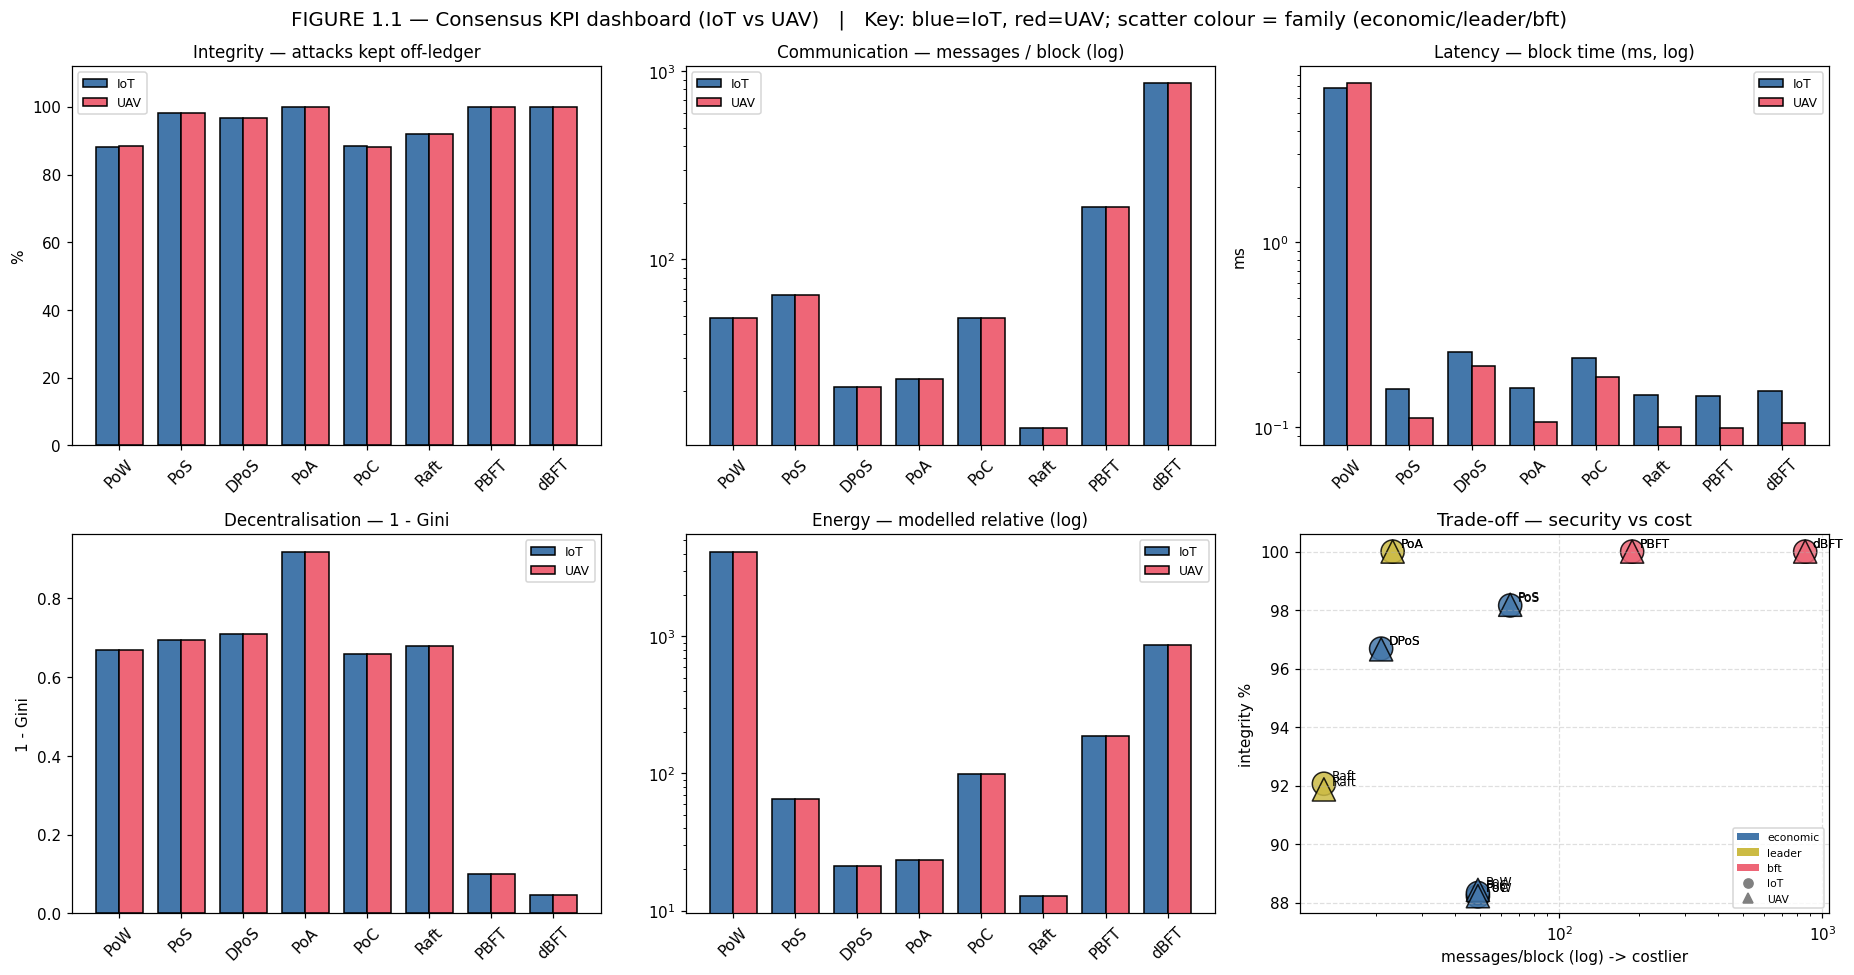

In [5]:
# ===== PART 1 · CELL 1.5 — Run on both datasets + consolidated KPI dashboard =====

# --- run every algorithm on both datasets, averaged over seeds ---
rows = []
for ds, stream, contract in [("IoT", iot_stream, iot_contract), ("UAV", uav_stream, uav_contract)]:
    for algo in ALGORITHMS:
        runs = [algo.run(stream, contract, seed=s, dataset=ds) for s in range(SEEDS)]
        rows.append({k: (np.mean([r[k] for r in runs]) if isinstance(runs[0][k], (int, float)) else runs[0][k])
                     for k in runs[0]})
results = pd.DataFrame(rows)
order = [a.name for a in ALGORITHMS]
fam   = {a.name: a.family for a in ALGORITHMS}
piv   = lambda c: results.pivot(index="algorithm", columns="dataset", values=c).reindex(order)

# --- KPI TABLE ---
tbl = pd.concat({
    "Integrity %":        (piv("integrity") * 100).round(1),
    "Msgs/block":         piv("msgs_per_block").round(0),
    "Block time (ms)":    piv("block_time_ms").round(2),
    "Decentralisation":   (1 - piv("gini")).round(3),
    "Energy (model)":     piv("energy_rel").round(1),
}, axis=1).swaplevel(axis=1).sort_index(axis=1, level=0)
print("TABLE 1.2 — Measured consensus KPIs (averaged over seeds)")
print("Key: Integrity = % attacks kept off-ledger (higher=better) | Decentralisation = 1-Gini (higher=better)")
print("     Energy = modelled relative units | all other KPIs measured\n")
print(tbl.to_string())

# --- CONSOLIDATED DASHBOARD (standard KPIs) ---
x, w = np.arange(len(order)), 0.38
fig, ax = plt.subplots(2, 3, figsize=(17, 9))
def dual(a, series, title, log=False, pct=False, ylab=""):
    d = series
    a.bar(x - w/2, d["IoT"], w, color=IOT_COLOR, edgecolor="black", label="IoT")
    a.bar(x + w/2, d["UAV"], w, color=UAV_COLOR, edgecolor="black", label="UAV")
    a.set_xticks(x, order, rotation=45); a.set_title(title, fontsize=11); a.set_ylabel(ylab)
    if log: a.set_yscale("log")
    if pct: a.set_ylim(0, 112)
    a.legend(fontsize=8)

dual(ax[0,0], piv("integrity")*100, "Integrity — attacks kept off-ledger", pct=True, ylab="%")
dual(ax[0,1], piv("msgs_per_block"), "Communication — messages / block (log)", log=True)
dual(ax[0,2], piv("block_time_ms"), "Latency — block time (ms, log)", log=True, ylab="ms")
dual(ax[1,0], 1 - piv("gini"), "Decentralisation — 1 - Gini", ylab="1 - Gini")
dual(ax[1,1], piv("energy_rel"), "Energy — modelled relative (log)", log=True)

# trade-off scatter (family-coloured) + key
for ds, mk in [("IoT", "o"), ("UAV", "^")]:
    r = results[results.dataset == ds].set_index("algorithm").reindex(order)
    ax[1,2].scatter(r["msgs_per_block"], r["integrity"]*100, s=230, marker=mk,
                    c=[FAMILY_COLOR[fam[a]] for a in order], edgecolors="black", alpha=0.85)
    for a in order:
        ax[1,2].annotate(a, (r["msgs_per_block"][a], r["integrity"][a]*100),
                         xytext=(5, 3), textcoords="offset points", fontsize=8)
ax[1,2].set_xscale("log"); ax[1,2].set_xlabel("messages/block (log) -> costlier")
ax[1,2].set_ylabel("integrity %"); ax[1,2].set_title("Trade-off — security vs cost")
ax[1,2].grid(True, ls="--", alpha=0.4)
ax[1,2].legend(handles=[Patch(facecolor=c, label=f) for f, c in FAMILY_COLOR.items()] +
               [plt.Line2D([], [], marker="o", ls="", color="grey", label="IoT"),
                plt.Line2D([], [], marker="^", ls="", color="grey", label="UAV")], fontsize=7, loc="lower right")
fig.suptitle("FIGURE 1.1 — Consensus KPI dashboard (IoT vs UAV)   |   Key: blue=IoT, red=UAV; "
             "scatter colour = family (economic/leader/bft)", fontsize=13)
plt.tight_layout(); plt.show()


# PART 2 — AI Misbehaviour Detection, Xai (LIME/SHAP) & Comparison

In [6]:
# ===== PART 2 · CELL 2.1 — Feature engineering for both datasets =====
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# --- transactions -> numeric feature frame (labels excluded) ---
def to_frame(txns, ds):
    f = pd.DataFrame([{**t["payload"], "sensor": t["device"]} for t in txns]) if ds == "IoT" \
        else pd.DataFrame([t["payload"] for t in txns])
    for c in f.columns:                                   # recover numeric dtypes
        z = pd.to_numeric(f[c], errors="coerce")
        if z.notna().sum() == f[c].notna().sum(): f[c] = z
    return f

# --- fitted preprocessor + split per dataset ---
def build(stream, ds, seed=42):
    frame = to_frame(stream, ds); cols = list(frame.columns)
    num = [c for c in cols if pd.api.types.is_numeric_dtype(frame[c])]
    cat = [c for c in cols if c not in num]
    pre = ColumnTransformer([
        ("n", Pipeline([("i", SimpleImputer(strategy="constant", fill_value=0)), ("s", StandardScaler())]), num),
        ("c", Pipeline([("i", SimpleImputer(strategy="constant", fill_value="NA")),
                        ("o", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat)])
    y = np.array([int(t["is_attack"]) for t in stream])
    tr, te = train_test_split(np.arange(len(stream)), test_size=0.30, stratify=y, random_state=seed)
    Xtr, Xte = pre.fit_transform(frame.iloc[tr]), pre.transform(frame.iloc[te])
    names = num + (list(pre.named_transformers_["c"].named_steps["o"].get_feature_names_out(cat)) if cat else [])
    return {"Xtr": Xtr, "Xte": Xte, "ytr": y[tr], "yte": y[te], "names": names,
            "test_txns": [stream[i] for i in te]}

DATA = {"IoT": build(iot_stream, "IoT"), "UAV": build(uav_stream, "UAV")}
for ds, d in DATA.items():
    print(f"{ds}: {d['Xtr'].shape[0]:,} train / {d['Xte'].shape[0]:,} test | {d['Xtr'].shape[1]} features "
          f"| {(d['yte']==0).sum():,} benign / {(d['yte']==1).sum():,} attack")


IoT: 29,400 train / 12,600 test | 38 features | 5,079 benign / 7,521 attack
UAV: 29,400 train / 12,600 test | 30 features | 7,985 benign / 4,615 attack


In [7]:
# ===== PART 2 · CELL 2.2 — Train the ten classical AI detectors =====
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, matthews_corrcoef, roc_curve)

def models_10():
    return {"Logistic Regression": LogisticRegression(max_iter=1000),
            "LDA": LinearDiscriminantAnalysis(), "Gaussian NB": GaussianNB(),
            "k-NN": KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=120, n_jobs=-1, random_state=42),
            "Extra Trees": ExtraTreesClassifier(n_estimators=120, n_jobs=-1, random_state=42),
            "AdaBoost": AdaBoostClassifier(random_state=42),
            "Hist GBM": HistGradientBoostingClassifier(random_state=42),
            "Linear SVM": LinearSVC(max_iter=5000)}

# --- attack-class score (probability, or scaled decision function) ---
def scores(clf, X):
    if hasattr(clf, "predict_proba"): return clf.predict_proba(X)[:, 1]
    d = clf.decision_function(X); return (d - d.min()) / (d.max() - d.min() + 1e-9)

# --- train + evaluate all models on both datasets ---
FITTED, CMS, ROCS, ROWS = {}, {}, {}, {}
for ds, d in DATA.items():
    FITTED[ds], CMS[ds], ROCS[ds], ROWS[ds] = {}, {}, {}, []
    for name, clf in models_10().items():
        t0 = time.perf_counter(); clf.fit(d["Xtr"], d["ytr"]); tt = time.perf_counter() - t0
        t0 = time.perf_counter(); yp = clf.predict(d["Xte"]); pt = time.perf_counter() - t0
        sc = scores(clf, d["Xte"]); tn, fp, fn, tp = confusion_matrix(d["yte"], yp).ravel()
        fpr, tpr, _ = roc_curve(d["yte"], sc)
        FITTED[ds][name] = clf; CMS[ds][name] = np.array([[tn, fp], [fn, tp]])
        ROCS[ds][name] = (fpr, tpr, roc_auc_score(d["yte"], sc))
        ROWS[ds].append({"Model": name, "Accuracy": accuracy_score(d["yte"], yp),
                         "Precision": precision_score(d["yte"], yp, zero_division=0),
                         "Recall": recall_score(d["yte"], yp), "F1": f1_score(d["yte"], yp),
                         "ROC-AUC": roc_auc_score(d["yte"], sc), "MCC": matthews_corrcoef(d["yte"], yp),
                         "FNR": fn / (fn + tp), "FPR": fp / (fp + tn),
                         "Latency (us/rec)": pt / len(d["yte"]) * 1e6, "Throughput (rec/s)": len(d["yte"]) / pt})

AI_KPIS = {ds: pd.DataFrame(ROWS[ds]).set_index("Model").sort_values("F1", ascending=False) for ds in DATA}
BEST = {ds: AI_KPIS[ds].index[0] for ds in DATA}
print("Trained 10 detectors on both datasets.")
print(f"  Best (F1): IoT -> {BEST['IoT']} ({AI_KPIS['IoT'].loc[BEST['IoT'],'F1']:.3f}) | "
      f"UAV -> {BEST['UAV']} ({AI_KPIS['UAV'].loc[BEST['UAV'],'F1']:.3f})")


Trained 10 detectors on both datasets.
  Best (F1): IoT -> Extra Trees (0.848) | UAV -> Hist GBM (0.961)


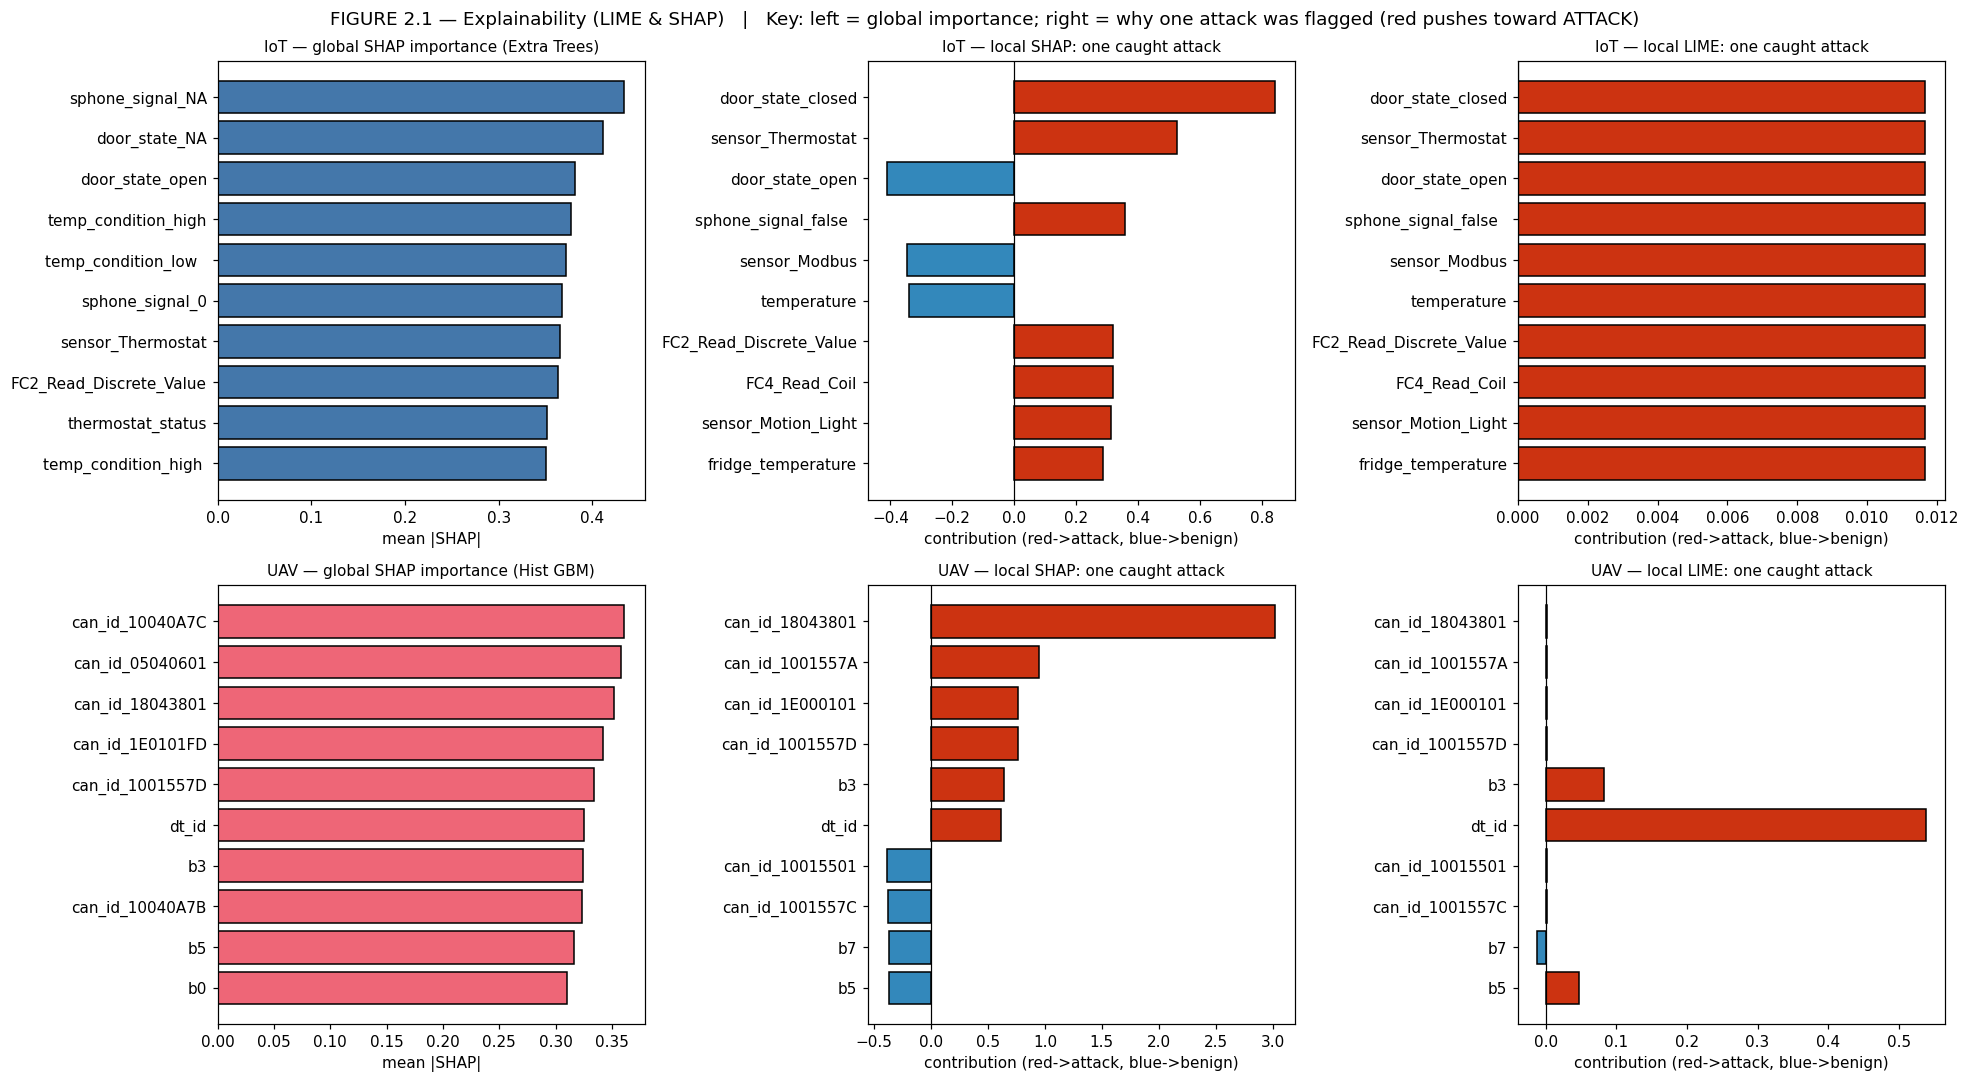

TABLE 2.1 — XAI summary
  IoT: top features = sphone_signal_NA, door_state_NA, door_state_open | SHAP/LIME top-10 agreement = 30%
  UAV: top features = can_id_10040A7C, can_id_05040601, can_id_18043801 | SHAP/LIME top-10 agreement = 40%


In [8]:
# ===== PART 2 · CELL 2.3 — Explainability: LIME & SHAP (from scratch) =====
from math import comb
from sklearn.linear_model import Ridge, LinearRegression

# --- LIME: weighted local linear surrogate over quartile-binned perturbations ---
class LIME:
    def __init__(self, Xtr, n=1000, seed=0):
        self.mu, self.sd = Xtr.mean(0), Xtr.std(0) + 1e-9
        b = np.percentile(Xtr, [25, 50, 75], axis=0); self.bins = b + np.arange(3).reshape(-1, 1) * 1e-9
        self.kw = np.sqrt(Xtr.shape[1]) * 0.75; self.n = n; self.rng = np.random.default_rng(seed)
    def _bin(self, Z): return np.stack([np.digitize(Z[:, j], self.bins[:, j]) for j in range(Z.shape[1])], 1)
    def explain(self, x, f):
        Z = self.rng.normal(self.mu, self.sd, (self.n, len(x))); Z[0] = x
        B = (self._bin(Z) == self._bin(x.reshape(1, -1))[0]).astype(float)
        w = np.exp(-((np.sqrt((((Z - x) / self.sd) ** 2).sum(1))) ** 2) / self.kw ** 2)
        m = Ridge(alpha=1.0); m.fit(B, f(Z), sample_weight=w); return m.coef_

# --- Kernel SHAP: Shapley values via the SHAP-kernel-weighted linear fit ---
class KernelSHAP:
    def __init__(self, bg, n=300, seed=0): self.bg, self.M, self.rng, self._b = bg, n, np.random.default_rng(seed), None
    def base(self, f):
        if self._b is None: self._b = float(f(self.bg).mean())
        return self._b
    def values(self, x, f):
        d = len(x); masks = np.zeros((self.M, d)); wt = np.zeros(self.M)
        for i in range(self.M):
            s = int(self.rng.integers(1, d)); idx = self.rng.choice(d, s, replace=False)
            masks[i, idx] = 1.0; wt[i] = (d - 1) / (comb(d, s) * s * (d - s))
        wt /= wt.sum()
        Z = masks * x + (1 - masks) * self.bg[self.rng.integers(0, len(self.bg), self.M)]
        m = LinearRegression(fit_intercept=False); m.fit(masks, f(Z) - self.base(f), sample_weight=wt)
        return m.coef_

def proba(clf): return lambda Z: clf.predict_proba(Z)[:, 1] if hasattr(clf, "predict_proba") else scores(clf, Z)

# --- global SHAP importance (mean|SHAP| over sampled records) + local LIME vs SHAP on one caught attack ---
GLOBAL_SHAP, AGREE = {}, {}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for r_, ds in enumerate(["IoT", "UAV"]):
    d = DATA[ds]; clf = FITTED[ds][BEST[ds]]; f = proba(clf); rng = np.random.default_rng(1)
    bg = d["Xtr"][rng.choice(len(d["Xtr"]), 200, replace=False)]
    lime, shap = LIME(d["Xtr"], seed=0), KernelSHAP(bg, seed=0)

    idx = rng.choice(len(d["Xte"]), 60, replace=False)
    phi = np.array([shap.values(d["Xte"][i], f) for i in idx])
    GLOBAL_SHAP[ds] = pd.Series(np.abs(phi).mean(0), index=d["names"]).sort_values(ascending=False)

    top = GLOBAL_SHAP[ds].head(10)[::-1]                               # global importance
    axes[r_, 0].barh(top.index, top.values, color=IOT_COLOR if ds == "IoT" else UAV_COLOR, edgecolor="black")
    axes[r_, 0].set_title(f"{ds} — global SHAP importance ({BEST[ds]})", fontsize=10)
    axes[r_, 0].set_xlabel("mean |SHAP|")

    hit = int(np.where((clf.predict(d["Xte"]) == 1) & (d["yte"] == 1))[0][0]); x = d["Xte"][hit]
    sv = pd.Series(shap.values(x, f), index=d["names"]); lv = pd.Series(lime.explain(x, f), index=d["names"])
    ti = sv.abs().sort_values(ascending=False).head(10).index
    for c_, (ser, ttl) in enumerate([(sv, "SHAP"), (lv, "LIME")], start=1):
        v = ser[ti][::-1]
        axes[r_, c_].barh(v.index, v.values, color=["#CC3311" if z > 0 else "#3388BB" for z in v], edgecolor="black")
        axes[r_, c_].axvline(0, color="black", lw=0.8)
        axes[r_, c_].set_title(f"{ds} — local {ttl}: one caught attack", fontsize=10)
        axes[r_, c_].set_xlabel("contribution (red->attack, blue->benign)")
    AGREE[ds] = len(set(sv.abs().nlargest(10).index) & set(lv.abs().nlargest(10).index)) / 10
fig.suptitle("FIGURE 2.1 — Explainability (LIME & SHAP)   |   Key: left = global importance; "
             "right = why one attack was flagged (red pushes toward ATTACK)", fontsize=12)
plt.tight_layout(); plt.show()

print("TABLE 2.1 — XAI summary")
for ds in DATA:
    print(f"  {ds}: top features = {', '.join(GLOBAL_SHAP[ds].head(3).index)} | "
          f"SHAP/LIME top-10 agreement = {AGREE[ds]:.0%}")


TABLE 2.2 — AI KPIs, IoT dataset (sorted by F1)
                     Accuracy  Precision  Recall     F1  ROC-AUC    MCC
Model                                                                  
Extra Trees             0.809      0.809   0.891  0.848    0.882  0.599
Random Forest           0.806      0.806   0.889  0.845    0.894  0.591
Decision Tree           0.797      0.801   0.878  0.837    0.815  0.571
Hist GBM                0.777      0.756   0.925  0.832    0.880  0.534
LDA                     0.738      0.705   0.963  0.814    0.813  0.464
Logistic Regression     0.729      0.702   0.949  0.807    0.814  0.438
Linear SVM              0.727      0.701   0.947  0.806    0.810  0.433
Gaussian NB             0.704      0.668   1.000  0.801    0.806  0.421
k-NN                    0.758      0.805   0.783  0.794    0.873  0.500
AdaBoost                0.683      0.653   1.000  0.790    0.799  0.373

TABLE 2.2 — AI KPIs, UAV dataset (sorted by F1)
                     Accuracy  Precisio

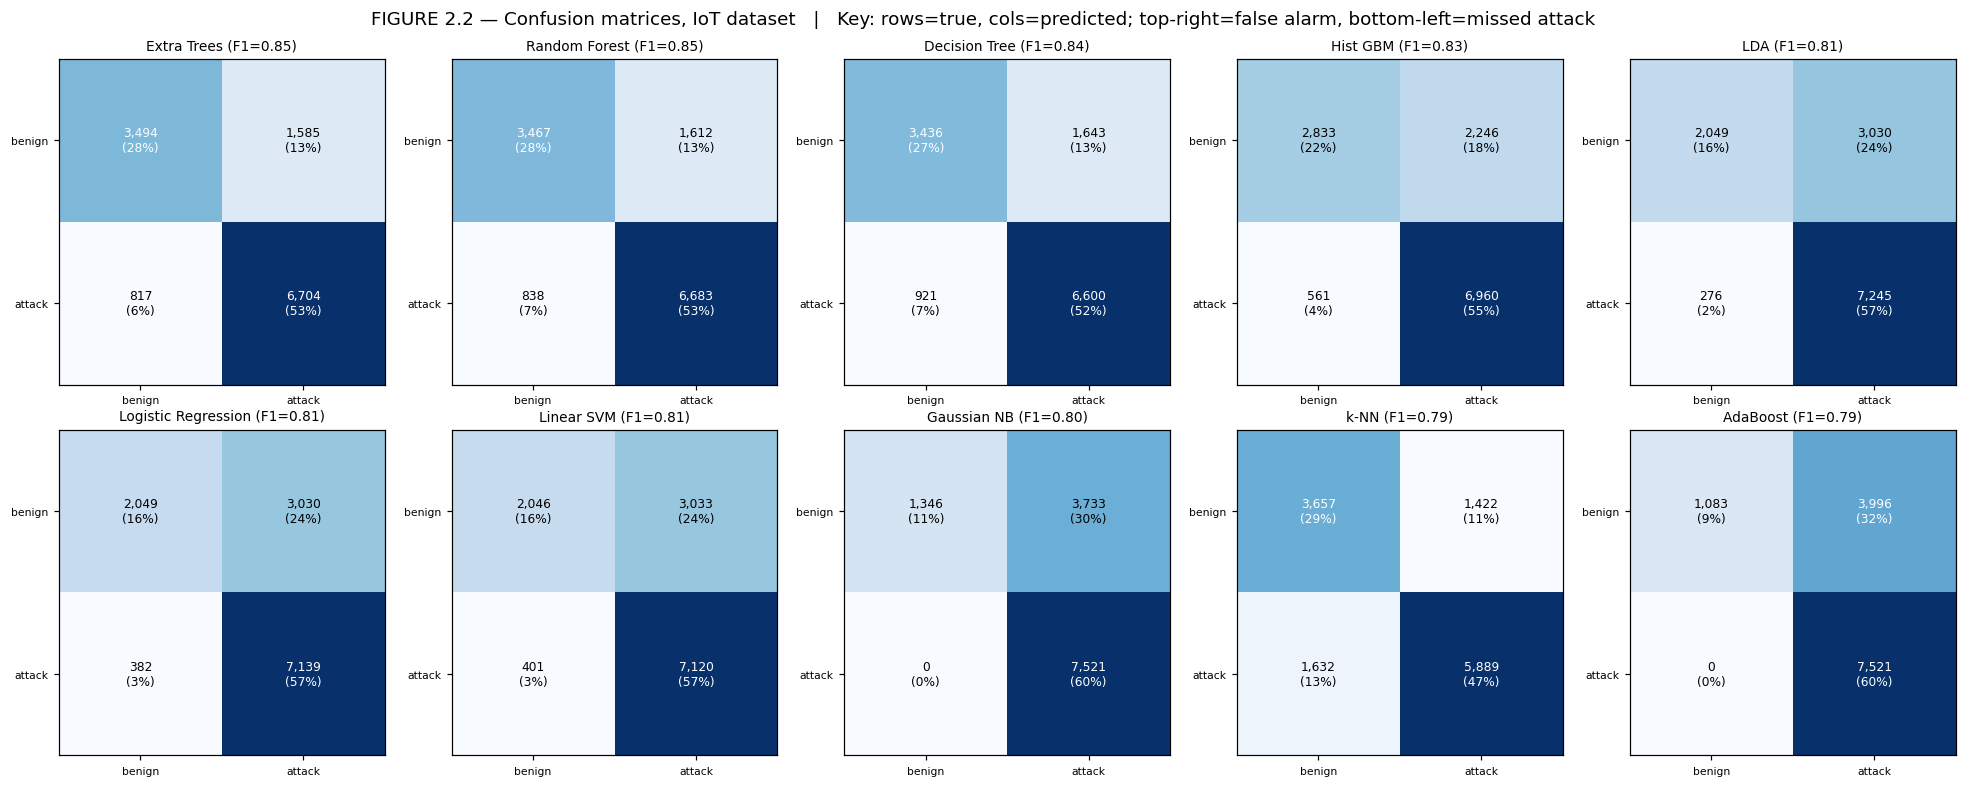

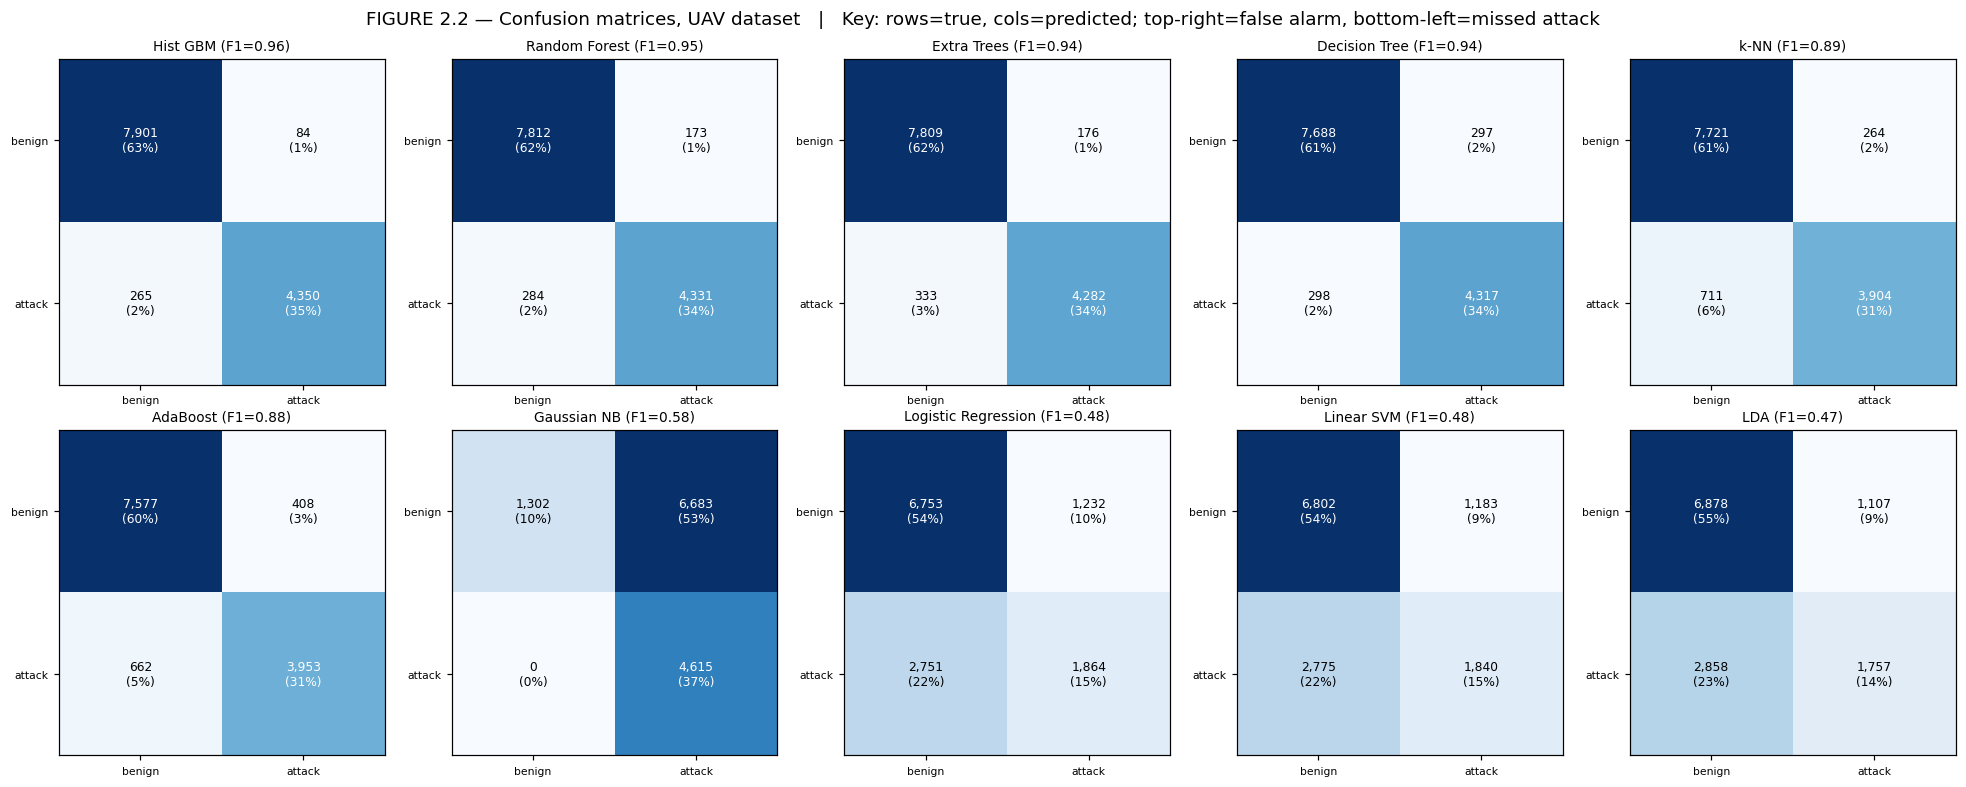

In [9]:
# ===== PART 2 · CELL 2.4 — AI & blockchain KPIs + confusion matrices =====
AI_COLS = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "MCC"]
BC_COLS = ["FNR", "FPR", "Latency (us/rec)", "Throughput (rec/s)"]

# --- KPI TABLES ---
for ds in DATA:
    print(f"TABLE 2.2 — AI KPIs, {ds} dataset (sorted by F1)")
    print(AI_KPIS[ds][AI_COLS].round(3).to_string()); print()
print("TABLE 2.3 — Blockchain KPIs (both datasets)")
print("Key: FNR = attacks admitted to ledger (security risk, lower=better) | "
      "FPR = valid records rejected (availability cost, lower=better)\n")
bc = pd.DataFrame(index=list(AI_KPIS["IoT"].index))
for ds in DATA:
    k = AI_KPIS[ds].reindex(bc.index)
    bc[f"{ds} FNR"] = (k["FNR"] * 100).round(1).astype(str) + "%"
    bc[f"{ds} FPR"] = (k["FPR"] * 100).round(1).astype(str) + "%"
    bc[f"{ds} Latency(us)"] = k["Latency (us/rec)"].round(1)
print(bc.to_string())

# --- CONFUSION MATRICES (10 per dataset) ---
for ds in ["IoT", "UAV"]:
    ms = list(AI_KPIS[ds].index)
    fig, axes = plt.subplots(2, 5, figsize=(18, 7.2))
    for ax, name in zip(axes.flat, ms):
        cm = CMS[ds][name]; tot = cm.sum()
        ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i,j]:,}\n({cm[i,j]/tot:.0%})", ha="center", va="center",
                        fontsize=8, color="white" if cm[i, j] > cm.max() * 0.5 else "black")
        ax.set_xticks([0, 1], ["benign", "attack"], fontsize=7); ax.set_yticks([0, 1], ["benign", "attack"], fontsize=7)
        ax.set_title(f"{name} (F1={AI_KPIS[ds].loc[name,'F1']:.2f})", fontsize=9)
    fig.suptitle(f"FIGURE 2.2 — Confusion matrices, {ds} dataset   |   "
                 "Key: rows=true, cols=predicted; top-right=false alarm, bottom-left=missed attack", fontsize=12)
    plt.tight_layout(); plt.show()


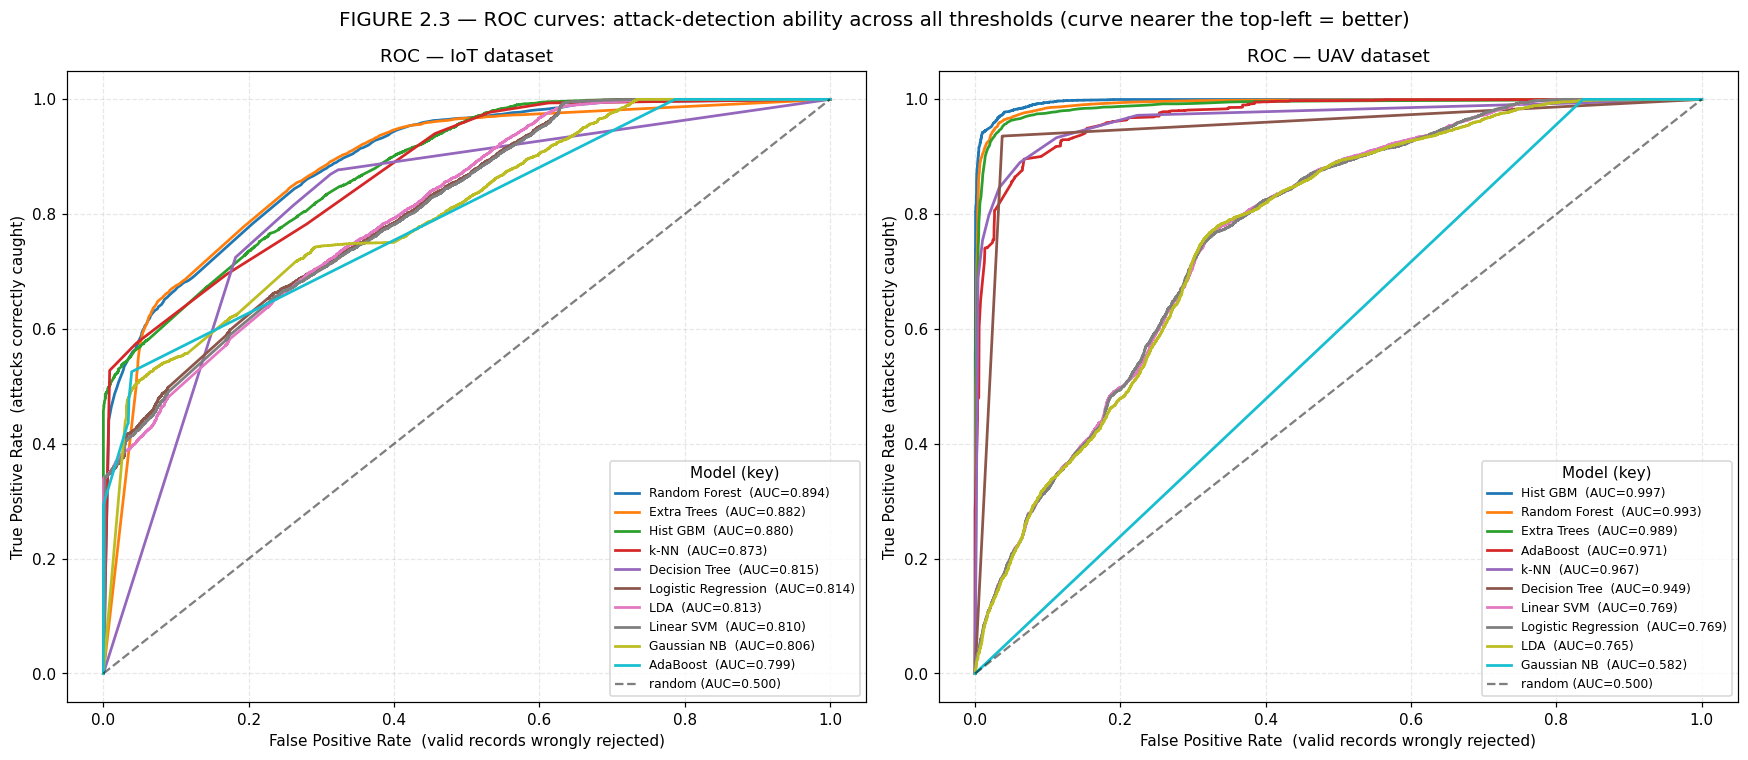

TABLE 2.4 — ROC Area Under Curve (AUC) by model and dataset (sorted by mean)

                       IoT    UAV   Mean
Random Forest        0.894  0.993  0.943
Hist GBM             0.880  0.997  0.938
Extra Trees          0.882  0.989  0.935
k-NN                 0.873  0.967  0.920
AdaBoost             0.799  0.971  0.885
Decision Tree        0.815  0.949  0.882
Logistic Regression  0.814  0.769  0.791
Linear SVM           0.810  0.769  0.790
LDA                  0.813  0.765  0.789
Gaussian NB          0.806  0.582  0.694

TABLE 2.5 — What ROC-AUC means
AUC = probability the model ranks a random ATTACK above a random BENIGN record.
  AUC range         Interpretation
0.90 - 1.00 Outstanding separation
0.80 - 0.90          Good / strong
0.70 - 0.80             Acceptable
0.60 - 0.70                   Poor
0.50 - 0.60      ≈ random guessing

0.5 = no better than a coin flip; 1.0 = perfect separation of attack from benign.


In [10]:
# ===== PART 2 · CELL 2.5 — ROC curves & AUC (primary comparison) =====

# --- ROC CURVES (both datasets, model+AUC in legend key) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, ds in zip(axes, ["IoT", "UAV"]):
    for name in AI_KPIS[ds].sort_values("ROC-AUC", ascending=False).index:
        fpr, tpr, auc = ROCS[ds][name]
        ax.plot(fpr, tpr, lw=1.8, label=f"{name}  (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="random (AUC=0.500)")
    ax.set_xlabel("False Positive Rate  (valid records wrongly rejected)")
    ax.set_ylabel("True Positive Rate  (attacks correctly caught)")
    ax.set_title(f"ROC — {ds} dataset", fontsize=12); ax.legend(fontsize=8, loc="lower right", title="Model (key)")
    ax.grid(True, ls="--", alpha=0.3)
fig.suptitle("FIGURE 2.3 — ROC curves: attack-detection ability across all thresholds "
             "(curve nearer the top-left = better)", fontsize=13)
plt.tight_layout(); plt.show()

# --- AUC TABLE ---
auc_tbl = pd.DataFrame({ds: {m: ROCS[ds][m][2] for m in ROCS[ds]} for ds in DATA})
auc_tbl["Mean"] = auc_tbl.mean(1)
auc_tbl = auc_tbl.sort_values("Mean", ascending=False)
print("TABLE 2.4 — ROC Area Under Curve (AUC) by model and dataset (sorted by mean)\n")
print(auc_tbl.round(3).to_string())

# --- AUC INTERPRETATION KEY ---
print("\nTABLE 2.5 — What ROC-AUC means")
print("AUC = probability the model ranks a random ATTACK above a random BENIGN record.")
print(pd.DataFrame({
    "AUC range": ["0.90 - 1.00", "0.80 - 0.90", "0.70 - 0.80", "0.60 - 0.70", "0.50 - 0.60"],
    "Interpretation": ["Outstanding separation", "Good / strong", "Acceptable", "Poor", "≈ random guessing"],
}).to_string(index=False))
print("\n0.5 = no better than a coin flip; 1.0 = perfect separation of attack from benign.")


TABLE 2.6 — Block-level detection (best detector per dataset)

  IoT: Extra Trees -> block accuracy 100.0% (200/200 abnormal caught, 0/200 benign false-flagged)
  UAV: Hist GBM -> block accuracy 100.0% (200/200 abnormal caught, 0/200 benign false-flagged)


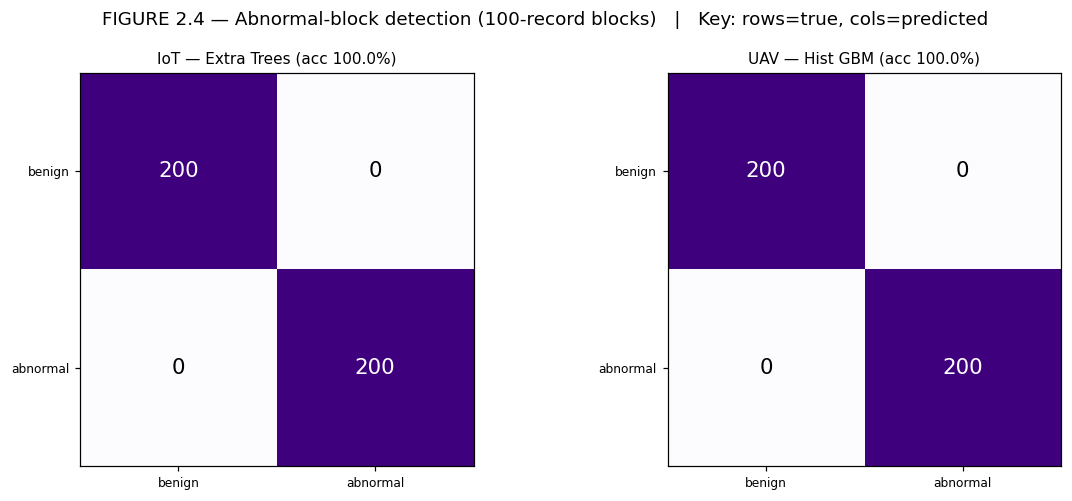

In [11]:
# ===== PART 2 · CELL 2.6 — Block-level misbehaviour detection =====
# Detect an abnormal BLOCK (the unit consensus commits): benign blocks are all-normal; adversarial
# blocks are 70% attack; flag a block when >=50% of its records are predicted malicious.
NB, MAL, THR = 200, 0.70, 0.50
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
print("TABLE 2.6 — Block-level detection (best detector per dataset)\n")
for ax, ds in zip(axes, ["IoT", "UAV"]):
    d = DATA[ds]; pred = FITTED[ds][BEST[ds]].predict(d["Xte"]); rng = np.random.default_rng(42)
    bi, ai = np.where(d["yte"] == 0)[0], np.where(d["yte"] == 1)[0]
    truth, flag = [], []
    for _ in range(NB):
        rows = rng.choice(bi, BLOCK_SIZE, replace=False); truth.append(0); flag.append(int(pred[rows].mean() >= THR))
    for _ in range(NB):
        k = int(BLOCK_SIZE * MAL)
        rows = np.concatenate([rng.choice(ai, k, replace=False), rng.choice(bi, BLOCK_SIZE - k, replace=False)])
        truth.append(1); flag.append(int(pred[rows].mean() >= THR))
    cm = confusion_matrix(truth, flag); acc = accuracy_score(truth, flag)
    ax.imshow(cm, cmap="Purples")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]}", ha="center", va="center", fontsize=14,
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    ax.set_xticks([0, 1], ["benign", "abnormal"], fontsize=8); ax.set_yticks([0, 1], ["benign", "abnormal"], fontsize=8)
    ax.set_title(f"{ds} — {BEST[ds]} (acc {acc:.1%})", fontsize=10)
    print(f"  {ds}: {BEST[ds]} -> block accuracy {acc:.1%} "
          f"({cm[1,1]}/{NB} abnormal caught, {cm[0,1]}/{NB} benign false-flagged)")
fig.suptitle(f"FIGURE 2.4 — Abnormal-block detection ({BLOCK_SIZE}-record blocks)   |   "
             "Key: rows=true, cols=predicted", fontsize=12)
plt.tight_layout(); plt.show()


# PART 3 — LLM-Assisted Interpretation & Mitigation (local models)

> Use a **GPU runtime** (for google colab: Runtime → Change runtime type → T4 GPU). First run downloads a few GB (~10-15 min).

In [12]:
# ===== PART 3 · CELL 3.0 — Local LLM setup on Colab
# Install zstd (required by the Ollama installer) + GPU helpers, then Ollama
!apt-get -qq update && apt-get -qq install -y zstd pciutils lshw
!curl -fsSL https://ollama.com/install.sh | sh
!pip -q install bert-score requests

import os, time, shutil, subprocess, requests
OLLAMA = shutil.which("ollama") or "/usr/local/bin/ollama"
assert os.path.exists(OLLAMA), "Ollama still not installed — read the curl output above."

OLLAMA_HOST, OLLAMA_MODELS = "http://127.0.0.1:11434", ["llama3.2", "qwen2.5:3b", "gemma2:2b"]
def _up():
    try: return requests.get(f"{OLLAMA_HOST}/api/tags", timeout=3).status_code == 200
    except Exception: return False
if not _up():
    subprocess.Popen([OLLAMA, "serve"], stdout=open("ollama.log","w"), stderr=subprocess.STDOUT)
    for _ in range(60):
        if _up(): break
        time.sleep(1)
print("Ollama server:", "up" if _up() else "NOT up — check ollama.log")
for m in OLLAMA_MODELS:
    print("pulling", m); subprocess.run([OLLAMA, "pull", m])
print("done:", OLLAMA_MODELS)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package pci.ids.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../0-pci.ids_0.0~2022.01.22-1ubuntu0.1_all.deb ...
Unpacking pci.ids (0.0~2022.01.22-1ubuntu0.1) ...
Selecting previously unselected package libpci3:amd64.
Preparing to unpack .../1-libpci3_1%3a3.7.0-6_amd64.deb ...
Unpacking libpci3:amd64 (1:3.7.0-6) ...
Selecting previously unselected package lshw.
Preparing to unpack .../2-lshw_02.19.git.2021.06.19.996aaad9c7-2ubuntu0.22.04.1_amd64.deb ...
Unpacking lshw (02.19.git.2021.06.19.996aaad9c7-2ubuntu0.22.04.1) ...
Selecting previously unselected package pciutils.
Preparing to unpack .../3-pciutils_1%3a3.7.0-6_amd64.deb ...
Unpacking pciutils (1:3.7.0-6) ...
Selecting previously unselected package usb.ids.
Prepari

In [13]:
# ===== PART 3 · CELL 3.1 — LLM configuration & local Ollama client =====
import ast, requests
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# config: local models via Ollama (free, no API keys); server started in Cell 3.0
USE_LOCAL_LLM = True                     # True = real local models; False = force offline simulation
OLLAMA_HOST   = "http://127.0.0.1:11434"
LLM_MODELS = [                           # three small, free local models
    {"name": "llama3.2",   "id": "llama3.2"},
    {"name": "qwen2.5:3b", "id": "qwen2.5:3b"},
    {"name": "gemma2:2b",  "id": "gemma2:2b"}]
RAG_SETTINGS  = ["No-RAG", "RAG"]        # agentic RAG intentionally omitted
N_LLM_SAMPLES = 6                        # caught attacks explained per dataset (raise for more data)
RAG_TOPK, LLM_SEED = 3, 7

# is the local server reachable? this decides REAL vs SIMULATION
def _ollama_up():
    try: return requests.get(f"{OLLAMA_HOST}/api/tags", timeout=3).status_code == 200
    except Exception: return False
_REAL = USE_LOCAL_LLM and _ollama_up()

# one real call to a local model (chat endpoint, non-streaming)
def _ollama_llm(model, prompt):
    t0 = time.perf_counter()
    r = requests.post(f"{OLLAMA_HOST}/api/chat", timeout=300,
        json={"model": model["id"], "stream": False, "options": {"temperature": 0.2},
              "messages": [{"role": "user", "content": prompt}]})
    r.raise_for_status()
    return r.json()["message"]["content"], time.perf_counter() - t0

# pull an explanation + a python policy rule out of free-form model text
def _parse_llm_text(text):
    m = re.search(r"```(?:python)?\s*(.*?)```", text, re.S)
    rule = m.group(1).strip() if m else "def policy(txn):\n    return None"
    return re.sub(r"```.*?```", "", text, flags=re.S).strip(), rule

# labelled offline fallback (used ONLY if the local server is unavailable)
def _sim_llm(model, setting, ctx, rng):
    cc = 0.72 + (0.06 if setting == "RAG" else 0.0)      # generic placeholder quality (NOT a real result)
    bt = 0.62 + (0.05 if setting == "RAG" else 0.0)
    sents = [s.strip() for s in ctx["reference"].split(". ") if s.strip()]
    k = float(np.clip(rng.normal((bt - 0.4) / 0.4, 0.05), 0.1, 1.0))
    expl = ". ".join(sents[:max(1, round(k * len(sents)))]) + \
           ". Overall, the classifier's decision is consistent with expected attack behaviour."
    p = float(np.clip((4 * cc - 1) / 3, 0, 1)); key, val = ctx["rule_key"], ctx["rule_val"]
    b_feat, b_cond, b_dec = rng.random() < p, rng.random() < p, rng.random() < p
    L = ["def policy(txn):", "    p = txn.get('payload', txn)"]
    if b_feat: L.append(f"    v = p.get('{key}')")
    if b_cond:
        cond = (f"v == '{val}'" if (b_feat and val is not None)
                else "v is not None and float(v) > THRESHOLD" if b_feat
                else "p.get('rate', 0) > THRESHOLD")
        L.append(f"    if {cond}:")
        L.append("        return 'reject'   # keep off-ledger" if b_dec else "        hits = 1")
    else:
        L.append("    return 'reject'" if b_dec else "    pass")
    lat = float(np.clip(rng.normal(2.5 if setting == "No-RAG" else 3.5, 0.4), 0.3, None))
    return expl, "\n".join(L), lat

# unified entry: local model if reachable, else labelled simulation, returns a source tag
def call_llm(model, setting, prompt, ctx, rng):
    if _REAL:
        try:
            text, latency = _ollama_llm(model, prompt); expl, rule = _parse_llm_text(text)
            return expl, rule, latency, "ollama"
        except Exception:
            expl, rule, latency = _sim_llm(model, setting, ctx, rng)
            return expl, rule, latency, "sim(fallback)"
    expl, rule, latency = _sim_llm(model, setting, ctx, rng)
    return expl, rule, latency, "sim"

print(f"LLM stage configured | mode = {'REAL (Ollama)' if _REAL else 'SIMULATION (server not reachable yet)'} | "
      f"models = {[m['name'] for m in LLM_MODELS]} | settings = {RAG_SETTINGS}")


LLM stage configured | mode = REAL (Ollama) | models = ['llama3.2', 'qwen2.5:3b', 'gemma2:2b'] | settings = ['No-RAG', 'RAG']


In [14]:
# ===== PART 3 · CELL 3.2 — Domain knowledge base + TF-IDF retriever (RAG) =====
KB_DOCS = [
    "UAVCAN flooding attack: an attacker injects CAN frames at very high rate to saturate the bus and starve legitimate traffic; mitigate with a per-identifier rate limit.",
    "UAVCAN fuzzy attack: frames carry random or malformed payload bytes but use valid CAN identifiers and legal data-length codes, so they are protocol-conformant and evade format rules.",
    "UAVCAN replay attack: previously valid frames are re-transmitted out of context; detection relies on payload and identifier patterns rather than on inter-frame timing.",
    "Key finding: UAV attacks in this study are protocol-conformant payload injections, not timing floods, so payload bytes and CAN identifier dominate detection while inter-frame gap ranks low.",
    "TON_IoT attack families include denial-of-service, distributed denial-of-service, backdoor, data injection, man-in-the-middle, password cracking, ransomware, scanning and cross-site scripting.",
    "Smart-contract RULE layer: a transaction is checked against a device or CAN-identifier registry, payload well-formedness such as a legal data-length code, and a per-identifier rate limit.",
    "Smart-contract POLICY layer: a pluggable anomaly detector returns a decision P(t) in {0,1}; a transaction is admitted only if it passes the rule layer and is not flagged by the policy.",
    "CAN identifier features (can_id_*) capture which electronic control unit sent a frame; unusual identifiers or unusual identifier-payload combinations are strong misbehaviour indicators.",
    "Payload byte features (b0..b7) encode the CAN data field; fuzzy and replay attacks shift the distribution of these bytes even when framing looks legal.",
    "Inter-frame gap features (dt) measure timing between frames; flooding compresses the gap, but fuzzy and replay attacks keep plausible timing.",
    "IoT sensor-state features such as door_state, sphone_signal, temp_condition and thermostat_status flip to unusual or missing (NA) values under injection and backdoor attacks.",
    "Modbus register features (FC1_*, FC2_*, FC3_*, FC4_*) expose read/write coil and register values; injection attacks write implausible register values.",
    "Mitigation pattern: rate-limit or temporarily quarantine an offending device or CAN identifier once the detector flags repeated anomalies.",
    "Mitigation pattern: tighten the on-chain policy by whitelisting expected payload ranges and data-length codes per identifier, and reject frames that deviate.",
    "Consensus context: authority-based and Byzantine-fault-tolerant consensus keep flagged attacks off the ledger, whereas crash-tolerant Raft can admit them, so the detector must feed the policy layer.",
    "Explainability context: SHAP attributes a prediction to features via Shapley values; LIME fits a local linear surrogate; agreement between them raises confidence in the flagged features."]
_kb_vec = TfidfVectorizer(stop_words="english").fit(KB_DOCS)
_kb_mat = _kb_vec.transform(KB_DOCS)
def retrieve(query, k=RAG_TOPK):         # top-k domain snippets for a query
    sims = cosine_similarity(_kb_vec.transform([query]), _kb_mat).ravel()
    return [KB_DOCS[i] for i in sims.argsort()[::-1][:k]]
print(f"Knowledge base ready | {len(KB_DOCS)} documents | TF-IDF retriever (top-{RAG_TOPK})")


Knowledge base ready | 16 documents | TF-IDF retriever (top-3)


In [15]:
# ===== PART 3 · CELL 3.3 — Build XAI context & prompts for sampled caught attacks =====
def _split_feature(name):                # one-hot feature name -> (payload key, value or None)
    if name in ("dt", "dt_id"): return "dt", None
    if re.fullmatch(r"b\d+", name):       return name, None
    m = re.match(r"(can_id)_([0-9A-Fa-f]+)$", name)
    if m: return m.group(1), m.group(2)
    if "_" in name:
        k, v = name.rsplit("_", 1); return k, v
    return name, None

def build_contexts(ds, n=N_LLM_SAMPLES):
    d = DATA[ds]; clf = FITTED[ds][BEST[ds]]; f = proba(clf); rng = np.random.default_rng(LLM_SEED)
    bg = d["Xtr"][rng.choice(len(d["Xtr"]), 150, replace=False)]
    shap, lime = KernelSHAP(bg, n=200, seed=1), LIME(d["Xtr"], n=600, seed=1)
    names = np.array(d["names"]); gtop = GLOBAL_SHAP[ds].head(5)
    norm_mu = d["Xtr"][d["ytr"] == 0].mean(0); atk_mu = d["Xtr"][d["ytr"] == 1].mean(0)
    caught = np.where((clf.predict(d["Xte"]) == 1) & (d["yte"] == 1))[0]
    pick = rng.choice(caught, min(n, len(caught)), replace=False)
    fam = "flooding/fuzzy/replay injection" if ds == "UAV" else "injection/backdoor"
    out = []
    for i in pick:
        x = d["Xte"][i]
        sv = pd.Series(shap.values(x, f), index=names); lv = pd.Series(lime.explain(x, f), index=names)
        s_top = sv.reindex(sv.abs().sort_values(ascending=False).index).head(6)
        l_top = lv.reindex(lv.abs().sort_values(ascending=False).index).head(6)
        f1, f2, f3 = [s_top.index[j] for j in range(3)]
        j1 = int(np.where(names == f1)[0][0]); hilo = "above" if x[j1] > norm_mu[j1] else "below"
        key, val = _split_feature(f1)
        nature = ("this reflects protocol-conformant payload injection rather than a timing flood"
                  if ds == "UAV" else "this reflects data injection or a backdoor rather than benign drift")
        ref = (f"The record was flagged as an attack on the {ds} network. "
               f"The strongest evidence is {f1}, whose value is {hilo} the normal mean. "
               f"Secondary contributors are {f2} and {f3}, consistent with a {fam} pattern. "
               f"For this traffic {nature}. "
               f"A suitable response is to tighten the on-chain policy around {key} and rate-limit the offending identifier. "
               f"The consensus layer then keeps the malicious record off the ledger")
        stats = "\n".join(f"    {nm:16s} normal_mu={norm_mu[int(np.where(names==nm)[0][0])]:+.2f} "
                          f"attack_mu={atk_mu[int(np.where(names==nm)[0][0])]:+.2f}" for nm in gtop.index)
        loc = "\n".join(f"    {nm:16s} SHAP={sv[nm]:+.3f}  LIME={lv.get(nm,0):+.3f}" for nm in s_top.index)
        base = (f"You are a security analyst for a blockchain-secured {ds} network.\n"
                f"General feature statistics (standardised, normal vs attack):\n{stats}\n"
                f"Model output: ATTACK (detector = {BEST[ds]}).\n"
                f"Local explanation — top contributing features:\n{loc}\n"
                f"Global top features: {', '.join(gtop.index)}.\n")
        task = ("\nTASK: (1) give a short human-readable explanation of why this frame is malicious; "
                "(2) propose a smart-contract POLICY rule in Python (function policy(txn)) that would "
                "block this pattern; (3) suggest one mitigation. Return the rule in a ```python``` block.")
        q = f"{ds} {f1} {f2} {f3} {fam} mitigation policy rule"
        prompt_norag = base + task
        prompt_rag   = base + "\nRetrieved domain context:\n" + \
            "\n".join(f"    - {s}" for s in retrieve(q)) + task
        out.append({"ds": ds, "reference": ref, "rule_key": key, "rule_val": val,
                    "true_feats": list(s_top.index), "prompt": {"No-RAG": prompt_norag, "RAG": prompt_rag}})
    return out

CTX = {ds: build_contexts(ds) for ds in DATA}
print(f"Built XAI contexts & prompts | " + " | ".join(f"{ds}: {len(CTX[ds])} attacks" for ds in DATA))
print("\n--- EXAMPLE RAG PROMPT (UAV, first instance) ---\n" + CTX["UAV"][0]["prompt"]["RAG"][:900] + " ...")


Built XAI contexts & prompts | IoT: 6 attacks | UAV: 6 attacks

--- EXAMPLE RAG PROMPT (UAV, first instance) ---
You are a security analyst for a blockchain-secured UAV network.
General feature statistics (standardised, normal vs attack):
    can_id_10040A7C  normal_mu=+0.04 attack_mu=+0.00
    can_id_05040601  normal_mu=+0.83 attack_mu=+1.00
    can_id_18043801  normal_mu=+0.00 attack_mu=+0.00
    can_id_1E0101FD  normal_mu=+0.00 attack_mu=+0.00
    can_id_1001557D  normal_mu=+0.00 attack_mu=+0.00
Model output: ATTACK (detector = Hist GBM).
Local explanation — top contributing features:
    can_id_1001557D  SHAP=-0.740  LIME=+0.015
    can_id_18043801  SHAP=-0.668  LIME=+0.015
    can_id_10015501  SHAP=+0.597  LIME=+0.015
    b6               SHAP=+0.572  LIME=-0.010
    can_id_05040601  SHAP=+0.481  LIME=+0.015
    can_id_10040A7D  SHAP=-0.435  LIME=+0.015
Global top features: can_id_10040A7C, can_id_05040601, can_id_18043801, can_id_1E0101FD, can_id_1001557D.

Retrieved domain conte

In [16]:
# ===== PART 3 · CELL 3.4 — Metrics: code-correctness rubric, BERTScore, timing =====
_DECISION = ("return", "reject", "block", "flag", "drop", "deny", "quarantine", "true", "false", "anomal")
def code_correctness(rule, true_feats):  # 5-criteria rubric in [0,1]
    try: ast.parse(rule); ok_parse = True
    except SyntaxError: ok_parse = False
    low  = rule.lower()
    body = "\n".join(l for l in rule.splitlines() if not l.strip().startswith("def ")).lower()
    top  = true_feats[0] if true_feats else ""                     # the single most important feature
    top_toks = {top.lower()} | {t.lower() for t in re.split(r"[^0-9a-zA-Z]+", top) if len(t) >= 2}
    ok_sig  = bool(re.search(r"def\s+policy\s*\(\s*txn\s*\)", rule))
    ok_feat = any(t in low for t in top_toks)                           # references the top feature
    ok_cond = bool(re.search(r"(>=|<=|==|!=|>|<|\bin\b)", rule))        # has a threshold/condition
    ok_dec  = any(w in body for w in _DECISION)                         # issues a decision
    return np.mean([ok_parse, ok_sig, ok_feat, ok_cond, ok_dec])

# BERTScore: real RoBERTa-large, RAW F1, TF-IDF proxy offline
_BERT_SCORER = None
def _get_bert_scorer():
    global _BERT_SCORER
    if _BERT_SCORER is None:
        from bert_score import BERTScorer                 # loads RoBERTa-large once, then caches
        _BERT_SCORER = BERTScorer(lang="en", rescale_with_baseline=False)   # raw F1 (no baseline subtraction)
    return _BERT_SCORER
def bert_score_fn(cand, ref):
    if _REAL:                                             # real BERTScore F1 (typically ~0.82-0.90)
        return float(_get_bert_scorer().score([cand], [ref])[2][0])
    v = TfidfVectorizer(stop_words="english").fit([cand, ref])
    cos = float(cosine_similarity(v.transform([cand]), v.transform([ref]))[0, 0])
    return float(np.clip(0.75 + 0.15 * cos, 0.0, 1.0))     # offline proxy in a comparable high band
print(f"Metrics ready | BERTScore backend = {'real bert-score (RoBERTa-large, raw F1)' if _REAL else 'TF-IDF proxy'}")


Metrics ready | BERTScore backend = real bert-score (RoBERTa-large, raw F1)


In [17]:
# ===== PART 3 · CELL 3.5 — Run evaluation: models x {No-RAG, RAG} =====
_REAL = USE_LOCAL_LLM and _ollama_up()
banner = "REAL — local Ollama models" if _REAL else "SIMULATION — offline fallback (DO NOT report these)"
print("=" * 70 + f"\n  MODE: {banner}\n" + "=" * 70)

#  warm up each local model once so timings exclude one-off model load (cold start)
if _REAL:
    print("warming up local models ...")
    for _m in LLM_MODELS:
        try: _ollama_llm(_m, "Reply with OK.")
        except Exception: pass

#  run every model x setting over the sampled attacks (tracks the source of each row)
rng = np.random.default_rng(LLM_SEED); rows, RAW = [], []
for model in LLM_MODELS:
    for setting in RAG_SETTINGS:
        for ds in DATA:
            for c in CTX[ds]:
                expl, rule, latency, source = call_llm(model, setting, c["prompt"][setting], c, rng)
                rows.append({"model": model["name"], "setting": setting, "dataset": ds, "source": source,
                             "code_correctness": code_correctness(rule, c["true_feats"]),
                             "bertscore": bert_score_fn(expl, c["reference"]),
                             "response_time": latency})
                RAW.append({"model": model["name"], "setting": setting, "dataset": ds,
                            "explanation": expl, "policy_rule": rule})
LLM_RES = pd.DataFrame(rows)

# provenance + save raw outputs for auditability
n_fb = int((LLM_RES["source"] != "ollama").sum())
if _REAL and n_fb: print(f"WARNING: {n_fb}/{len(LLM_RES)} calls fell back to simulation (see 'source' column).")
LLM_RES.to_csv("part3_llm_results.csv", index=False)
pd.DataFrame(RAW).to_csv("part3_llm_raw_outputs.csv", index=False)
print(f"Saved part3_llm_results.csv ({len(LLM_RES)} rows) + part3_llm_raw_outputs.csv")

# Table 3.1: mean +/- 95% CI per model x setting
def _ci(x): return 1.96 * x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
def summary(metric, title):
    g = LLM_RES.groupby(["setting", "model"])[metric]; mean = g.mean().unstack(); ci = g.agg(_ci).unstack()
    print(f"\n{title}")
    print("  " + "".join(f"{m:>18s}" for m in mean.columns))
    for s in RAG_SETTINGS:
        print(f"  {s:8s}" + "".join(f"{mean.loc[s, m]:8.3f} \u00b1 {ci.loc[s, m]:5.3f}" for m in mean.columns))
print(f"\nTABLE 3.1 — LLM interpretation quality (mean \u00b1 95% CI over sampled attacks, both datasets)")
summary("code_correctness", "Modified Code Correctness"); summary("bertscore", "BERTScore")
summary("response_time", "Average Response Time (s)")


  MODE: REAL — local Ollama models
warming up local models ...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Saved part3_llm_results.csv (72 rows) + part3_llm_raw_outputs.csv

TABLE 3.1 — LLM interpretation quality (mean ± 95% CI over sampled attacks, both datasets)

Modified Code Correctness
           gemma2:2b          llama3.2        qwen2.5:3b
  No-RAG     0.950 ± 0.051   0.950 ± 0.051   0.933 ± 0.056
  RAG        0.917 ± 0.058   0.900 ± 0.076   0.917 ± 0.058

BERTScore
           gemma2:2b          llama3.2        qwen2.5:3b
  No-RAG     0.819 ± 0.006   0.839 ± 0.003   0.835 ± 0.004
  RAG        0.823 ± 0.004   0.838 ± 0.004   0.842 ± 0.005

Average Response Time (s)
           gemma2:2b          llama3.2        qwen2.5:3b
  No-RAG     8.280 ± 1.486   5.737 ± 0.775  12.229 ± 1.706
  RAG        8.123 ± 0.650   8.126 ± 1.118  14.105 ± 2.264


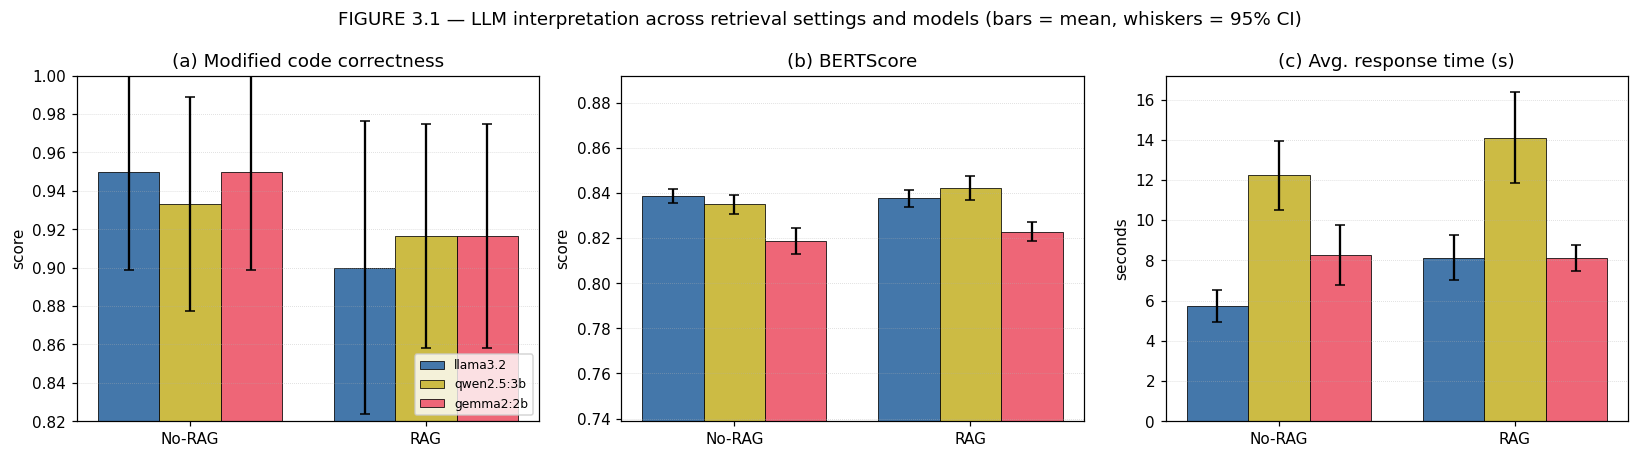

In [18]:
# ===== PART 3 · CELL 3.6 — Figure: correctness / BERTScore / response time (like Fig. 4) =====
_PAL = ["#4477AA", "#CCBB44", "#EE6677", "#66AA55", "#AA4499", "#228833"]
COLL = {m["name"]: _PAL[i % len(_PAL)] for i, m in enumerate(LLM_MODELS)}   # colour per configured model
panels = [("code_correctness", "(a) Modified code correctness", "score"),
          ("bertscore", "(b) BERTScore", "score"), ("response_time", "(c) Avg. response time (s)", "seconds")]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2)); x = np.arange(len(RAG_SETTINGS)); w = 0.26
for a, (metric, title, ylab) in zip(ax, panels):
    g = LLM_RES.groupby(["setting", "model"])[metric]; mean = g.mean().unstack(); ci = g.agg(_ci).unstack()
    for j, m in enumerate([mm["name"] for mm in LLM_MODELS]):
        a.bar(x + (j - 1) * w, mean[m].reindex(RAG_SETTINGS), w, yerr=ci[m].reindex(RAG_SETTINGS),
              capsize=3, color=COLL[m], edgecolor="black", lw=.5, label=m)
    a.set_xticks(x, RAG_SETTINGS); a.set_title(title); a.set_ylabel(ylab)
    if metric == "response_time":
        a.set_ylim(bottom=0)
    else:                                             # zoom score panels to reveal differences
        lo = max(0.0, float(mean.values.min()) - 0.08); hi = min(1.02, float(mean.values.max()) + 0.05)
        a.set_ylim(lo, hi if hi > lo + 0.06 else lo + 0.12)
    a.grid(axis="y", ls=":", lw=.5, alpha=.6)
ax[0].legend(fontsize=8, loc="lower right")
fig.suptitle("FIGURE 3.1 — LLM interpretation across retrieval settings and models "
             "(bars = mean, whiskers = 95% CI)" + ("" if _REAL else "   [SIMULATION]"), fontsize=12)
plt.tight_layout(); plt.show()
